# Tutorial 15: Supervisor Agent with LangGraph

In this tutorial we build a hierarchical multi-agent system using the `langgraph-supervisor` package. A central Supervisor LLM coordinates a team of specialised worker agents, delegating tasks via tool calls and aggregating their results.

## 1. The Supervisor Pattern

In the Supervisor architecture:
- The **Supervisor** receives every user message and decides which worker to call
- **Workers** are independent agents, each with their own tools and prompts
- Workers return results to the Supervisor, which synthesises a final response
- All communication flows through the Supervisor — workers never talk directly to each other

```
User → Supervisor → Worker A
                  → Worker B
       Supervisor ← results
User ← Supervisor
```

## 2. Setup

In [1]:
import os
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

from langchain_groq import ChatGroq
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.prebuilt import create_react_agent
from langgraph_supervisor import create_supervisor

# Stronger, more reliable model for multi-agent orchestration/tool routing
llm = ChatGroq(model_name="llama-3.3-70b-versatile", temperature=0.1)

print("Setup complete.")

[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Setup complete.


## 3. How `langgraph-supervisor` Works

Internally, `create_supervisor` builds a graph where:
1. The **Supervisor** is itself a `create_react_agent` with auto-generated handoff tools (`transfer_to_<agent_name>`)
2. When the supervisor calls `transfer_to_web_search_agent`, LangGraph executes the corresponding worker node
3. The worker completes its task and **returns automatically** to the supervisor
4. The supervisor decides the next step or calls `END`

> **Groq note**: by default the package adds fake `transfer_back_to_supervisor` messages
> that Groq rejects because they were not in the tools list.
> Fix: `add_handoff_back_messages=False`

## 4. Defining Tools

Tools are simple Python functions with clear docstrings. Workers receive them via `create_react_agent` and the model decides when to call them.

In [2]:
@tool
def search_web(query: str) -> str:
    """Search the web for information on a topic. Use a short query."""
    return (
        f"[Web: '{query}'] Renewable energy capacity grew 40% YoY. "
        "Solar and wind now cover 30% of global electricity."
    )

@tool
def get_news(topic: str) -> str:
    """Get the latest news on a topic. Use a short topic keyword."""
    return (
        f"[News: '{topic}'] EU approved €500B green energy package. "
        "US solar installations hit a record high in Q1 2025."
    )

@tool
def analyse_data(description: str) -> str:
    """Analyse data and return statistical insights."""
    return (
        f"[Analysis: '{description}'] Trend: strong upward. "
        "CAGR: 22%. Forecast: 60% renewables by 2030."
    )

@tool
def write_report(findings: str) -> str:
    """Write a structured summary report from research findings."""
    from langchain_core.messages import HumanMessage as HM
    resp = llm.invoke([HM(content=f"Write a 5-bullet summary report from:\n{findings}")])
    return resp.content

print("Tools defined.")

Tools defined.


## 5. Creating Worker Agents

Each worker is a standard `create_react_agent`. The `name` parameter is required — `create_supervisor` uses it to auto-generate the handoff tool `transfer_to_<name>`.

In [3]:
web_search_agent = create_react_agent(
    model=llm,
    tools=[search_web, get_news],
    name="web_search_agent",
    prompt="You are a web research specialist. Use short queries (3-6 words). Call each tool once."
)

data_analyst_agent = create_react_agent(
    model=llm,
    tools=[],
    name="data_analyst_agent",
    prompt=(
        "You are a data analyst. Analyse the provided findings and produce a clear summary report "
        "directly in text without calling tools."
    )
)

print("Worker agents created.")

Worker agents created.


## 6. Creating the Supervisor

`create_supervisor` automatically generates handoff tools for each worker. The key parameter for Groq is `add_handoff_back_messages=False` — it prevents fake `transfer_back_to_supervisor` messages that Groq rejects.

In [4]:
supervisor = create_supervisor(
    agents=[web_search_agent, data_analyst_agent],
    model=llm,
    prompt=(
        "You are a research team supervisor managing a web_search_agent and a data_analyst_agent.\n"
        "Workflow: first delegate to web_search_agent to gather information, "
        "then delegate to data_analyst_agent to analyse and write the report.\n"
        "Respond only when the final report is ready."
    ),
    output_mode="last_message",           # restituisce solo l'ultimo messaggio
    add_handoff_back_messages=False,      # fix per Groq: no messaggi finti transfer_back
).compile()

print("Supervisor compiled.")

Supervisor compiled.


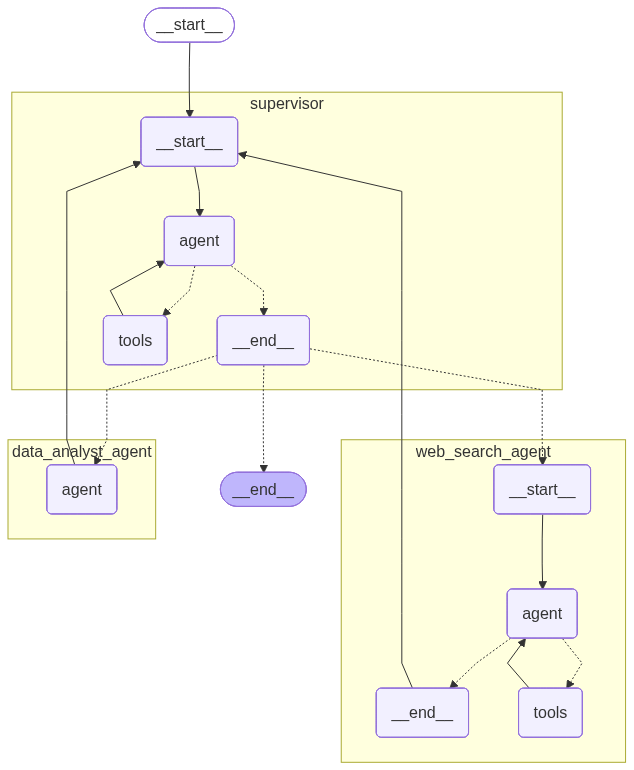

In [5]:
from IPython.display import Image, display
display(Image(supervisor.get_graph(xray=True).draw_mermaid_png()))

## 7. Running the Supervisor

In [6]:
result = supervisor.invoke({
    "messages": [HumanMessage(content="Research the current state of renewable energy adoption and give me a summary report.")]
})

# In last_message mode, trailing handoff/tool messages can have empty content.
# Print the last non-empty textual message instead.
final_text = ""
for msg in reversed(result["messages"]):
    content = getattr(msg, "content", None)
    if isinstance(content, str) and content.strip():
        final_text = content
        break

print(final_text if final_text else "[No textual final response produced]")

The current state of renewable energy adoption is characterized by significant growth and increasing investment in solar and wind power, as well as other forms of renewable energy. Here is a summary report:

**Global Trends:**

1. **Renewable energy capacity:** The world's renewable energy capacity has reached 3,372 gigawatts (GW), with solar and wind power accounting for 37% and 36% of the total, respectively.
2. **Investment:** Global investment in renewable energy reached $1.3 trillion in 2020, with solar energy attracting the largest share of investment.
3. **Energy mix:** Renewables now account for 26% of global electricity generation, up from 21% in 2015.

**Regional Highlights:**

1. **Asia-Pacific:** The region is leading the way in renewable energy adoption, with China, India, and Japan driving growth.
2. **Europe:** The European Union has set ambitious renewable energy targets, with many countries exceeding their goals.
3. **United States:** The US has seen significant growth

## 8. Output Mode: full_history

With `output_mode="full_history"` you can see all intermediate messages from each worker agent.

In [7]:
supervisor_full = create_supervisor(
    agents=[web_search_agent, data_analyst_agent],
    model=llm,
    prompt=(
        "You are a research team supervisor. "
        "Delegate to web_search_agent first, then data_analyst_agent."
    ),
    output_mode="full_history",
    add_handoff_back_messages=False,
).compile()

result_full = supervisor_full.invoke({
    "messages": [HumanMessage(content="What are the latest trends in AI?")]
})

print(f"Total messages: {len(result_full['messages'])}\n")
for msg in result_full["messages"]:
    name = getattr(msg, "name", None) or msg.__class__.__name__
    content = str(msg.content)[:80] if msg.content else "[tool call]"
    print(f"  [{name}]: {content}")

Total messages: 5

  [HumanMessage]: What are the latest trends in AI?
  [supervisor]: [tool call]
  [transfer_to_data_analyst_agent]: Successfully transferred to data_analyst_agent
  [data_analyst_agent]: The latest trends in AI include the increasing use of deep learning techniques, 
  [supervisor]: [tool call]


## 9. Multi-Level Hierarchy

A compiled supervisor can itself be used as a worker in a higher-level supervisor. Just compile it with an explicit `name` parameter.

In [8]:
@tool
def save_document(content: str, filename: str) -> str:
    """Save content to a document file."""
    return f"Document '{filename}' saved ({len(content)} chars)."

writer_agent = create_react_agent(
    model=llm,
    tools=[],
    name="writer_agent",
    prompt=(
        "You are a technical writer. Write a polished document from the provided findings "
        "directly in text. Do not call any tools."
    )
)

# The research team becomes a worker in the top-level supervisor
research_team = create_supervisor(
    agents=[web_search_agent, data_analyst_agent],
    model=llm,
    prompt="You coordinate research: search first, then analyse.",
    output_mode="last_message",
    add_handoff_back_messages=False,
    supervisor_name="research_supervisor",
).compile(name="research_team")  # name required to use it as a worker

top_supervisor = create_supervisor(
    agents=[research_team, writer_agent],
    model=llm,
    prompt=(
        "You are the project manager. "
        "Use research_team to gather and analyse information, "
        "then use writer_agent to produce the final document."
    ),
    output_mode="last_message",
    add_handoff_back_messages=False,
).compile()

result_top = top_supervisor.invoke({
    "messages": [HumanMessage(content="Research quantum computing trends and write a brief report.")]
})

final_text_top = ""
for msg in reversed(result_top["messages"]):
    content = getattr(msg, "content", None)
    if isinstance(content, str) and content.strip():
        final_text_top = content
        break

print(final_text_top if final_text_top else "[No textual final response produced]")

Quantum Computing Trends Report

Introduction:
Quantum computing is a rapidly evolving field that has gained significant attention in recent years. This report provides an overview of the current trends in quantum computing, highlighting the key developments, advancements, and future prospects.

Current Trends:

1. **Increased Investment**: There has been a significant increase in investment in quantum computing research and development, with governments, corporations, and venture capitalists pouring billions of dollars into the field.
2. **Advancements in Quantum Hardware**: Significant progress has been made in the development of quantum hardware, including the creation of more powerful and stable quantum processors, improved quantum gates, and the development of new materials and technologies.
3. **Quantum Software and Algorithms**: There has been a growing focus on the development of quantum software and algorithms, including the creation of new programming languages, software fram

## 10. Conclusion

In this tutorial we built a hierarchical multi-agent system with the Supervisor pattern:
- `create_supervisor(agents, model, prompt, output_mode, add_handoff_back_messages)` wires workers under a central coordinator
- `output_mode="last_message"` returns only the final response; `"full_history"` exposes all intermediate messages
- `add_handoff_back_messages=False` is required for Groq to avoid tool validation errors
- Workers are standard `create_react_agent` instances — each needs a unique `name`
- Supervisors can be nested: compile a supervisor with `name=` to use it as a worker in a higher-level supervisor

In Tutorial 16 we explore the Swarm pattern — a decentralised alternative where agents pass control directly to each other via peer-to-peer handoff tools.